In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.manifold import TSNE
import re
import textwrap

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

In [3]:
newsgroups = fetch_20newsgroups(
    subset="all",
    remove=("headers", "footers", "quotes")  # helps reduce “email-like” noise
)

df = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target,
    "target_name": [newsgroups.target_names[i] for i in newsgroups.target]
})

df.head(), df.shape

(                                                text  target  \
 0  \n\nI am sure some bashers of Pens fans are pr...      10   
 1  My brother is in the market for a high-perform...       3   
 2  \n\n\n\n\tFinally you said what you dream abou...      17   
 3  \nThink!\n\nIt's the SCSI card doing the DMA t...       3   
 4  1)    I have an old Jasmine drive which I cann...       4   
 
                 target_name  
 0          rec.sport.hockey  
 1  comp.sys.ibm.pc.hardware  
 2     talk.politics.mideast  
 3  comp.sys.ibm.pc.hardware  
 4     comp.sys.mac.hardware  ,
 (18846, 3))

In [7]:
type(newsgroups)
print(f"Number of documents: {len(newsgroups.data)}")
print(f"Number of categories: {len(newsgroups.target_names)}")
print(f"Categories: {newsgroups.target_names}")

Number of documents: 18846
Number of categories: 20
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


#### Basic text sanity checks + length visualizations

            char_len      word_len
count   18846.000000  18846.000000
mean     1169.667516    181.637748
std      3858.748875    501.333800
min         0.000000      0.000000
50%       489.000000     83.000000
90%      1985.000000    331.000000
95%      3396.750000    558.000000
99%     12128.300000   1750.800000
max    158791.000000  11765.000000


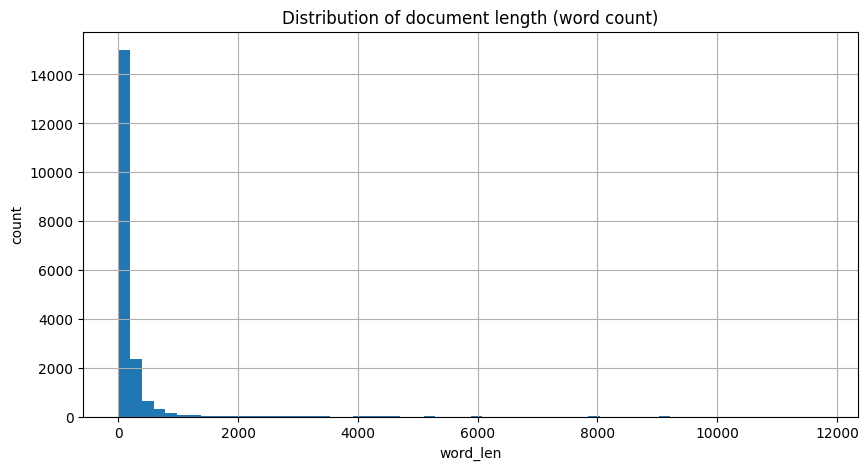

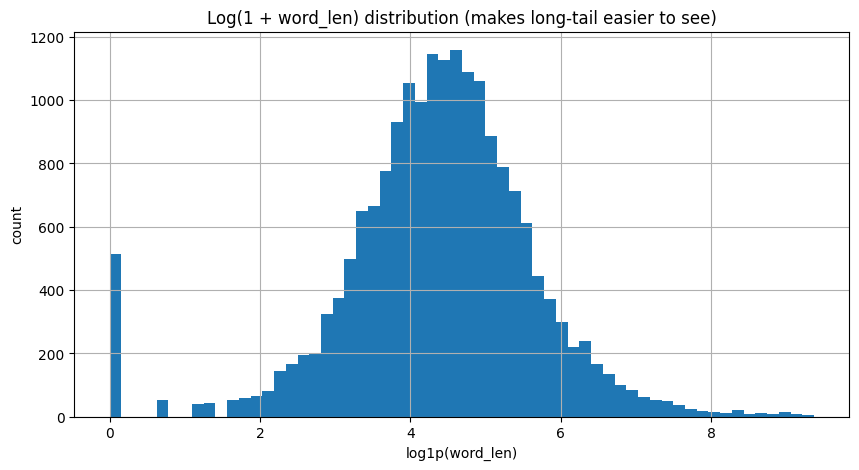

In [8]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].apply(lambda x: len(str(x).split()))

print(df[["char_len", "word_len"]].describe(percentiles=[.5, .9, .95, .99]))

fig, ax = plt.subplots()
ax.hist(df["word_len"], bins=60)
ax.set_title("Distribution of document length (word count)")
ax.set_xlabel("word_len")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots()
ax.hist(np.log1p(df["word_len"]), bins=60)
ax.set_title("Log(1 + word_len) distribution (makes long-tail easier to see)")
ax.set_xlabel("log1p(word_len)")
ax.set_ylabel("count")
plt.show()

### cleaning using regex

In [9]:
url_re = re.compile(r"(http|https)://\S+|www\.\S+")
ws_re = re.compile(r"\s+")

def clean_text(s: str) -> str:
    s = str(s)
    s = url_re.sub(" URL ", s)
    s = s.replace("\n", " ")
    s = ws_re.sub(" ", s).strip()
    return s

df["clean_text"] = df["text"].apply(clean_text)

# Show one example
i = np.random.randint(0, len(df))
print("RAW:\n", textwrap.shorten(df.loc[i, "text"], width=400))
print("\nCLEAN:\n", textwrap.shorten(df.loc[i, "clean_text"], width=400))

RAW:
 Reading newspapers to learn about this kind of stuff is not the best idea in the world. Newspaper reporters are notoriously ignorant on the subject of religion, and are prone to exaggeration in the interests of having a "real" story (that is, a bigger headline). Let's back up to 1935. At this point, we have the Masoretic text, the various targums (translations/commentaries in aramaic, etc.), [...]

CLEAN:
 Reading newspapers to learn about this kind of stuff is not the best idea in the world. Newspaper reporters are notoriously ignorant on the subject of religion, and are prone to exaggeration in the interests of having a "real" story (that is, a bigger headline). Let's back up to 1935. At this point, we have the Masoretic text, the various targums (translations/commentaries in aramaic, etc.), [...]


In [10]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.6,        # ignore extremely common terms
    min_df=5,          # ignore extremely rare terms
    ngram_range=(1, 2),# unigrams + bigrams helps clustering
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["clean_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Sparsity:", 1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])))

TF-IDF matrix shape: (18846, 48206)
Sparsity: 0.9985741476444818


In [17]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline


svd= TruncatedSVD(n_components=100)

x_lsa= make_pipeline(svd, Normalizer(copy=False))

# x_lsa defines latent semantic analysis (LSA) pipeline: SVD for dimensionality reduction + normalization
x_lsa= x_lsa.fit_transform(X_tfidf)
print("LSA-reduced matrix shape:", x_lsa.shape)


LSA-reduced matrix shape: (18846, 100)


LSA shape: (18846, 100)
Explained variance ratio (sum): 0.078


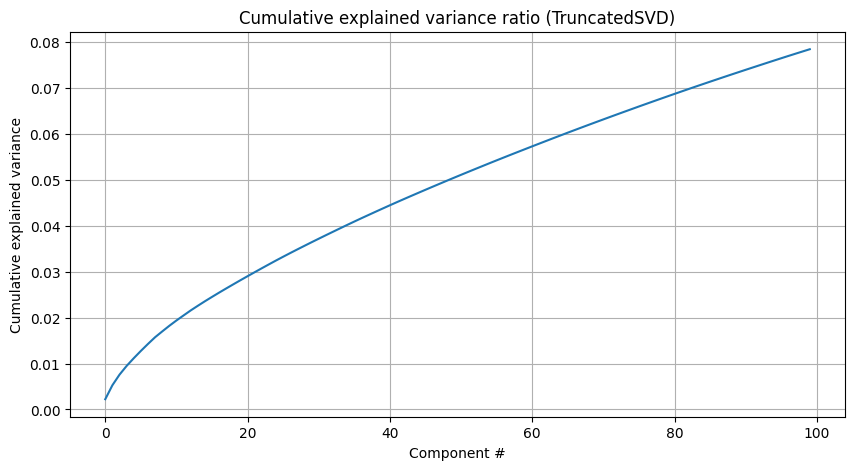

In [18]:
explained = svd.explained_variance_ratio_.sum()
print(f"LSA shape: {x_lsa.shape}")
print(f"Explained variance ratio (sum): {explained:.3f}")

fig, ax = plt.subplots()
ax.plot(np.cumsum(svd.explained_variance_ratio_))
ax.set_title("Cumulative explained variance ratio (TruncatedSVD)")
ax.set_xlabel("Component #")
ax.set_ylabel("Cumulative explained variance")
plt.show()

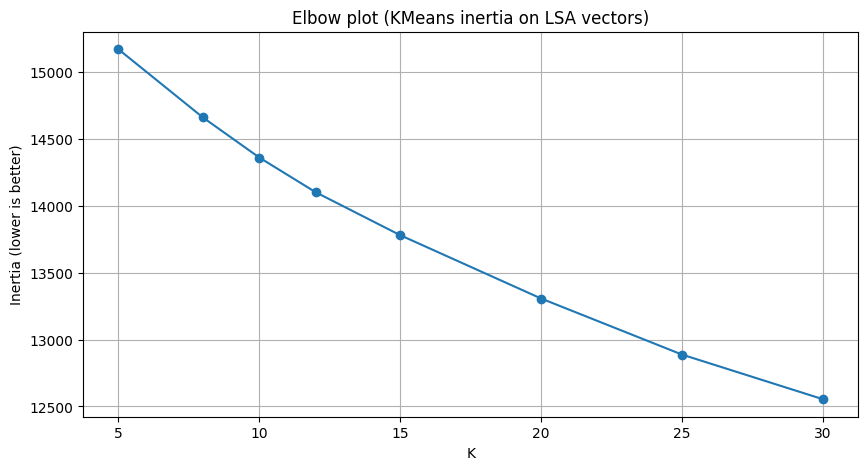

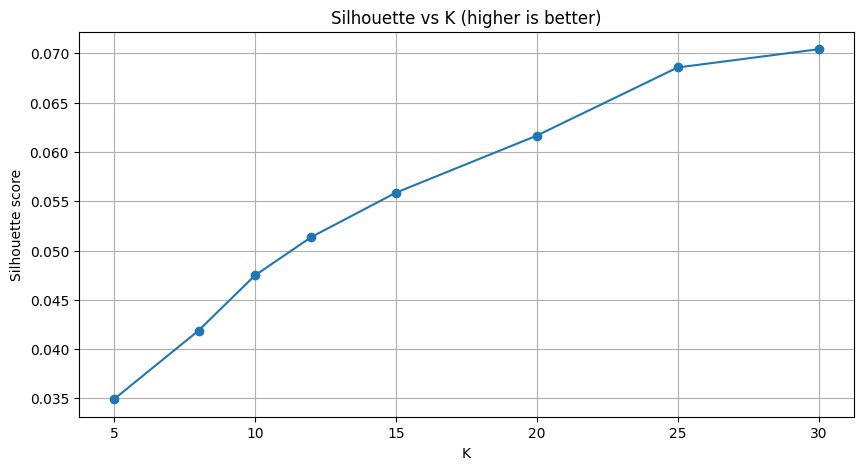

Best K by silhouette (from tested Ks): 30


In [20]:
Ks = [5, 8, 10, 12, 15, 20, 25, 30]
inertias = []
silhs = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(x_lsa)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(x_lsa, labels))

fig, ax = plt.subplots()
ax.plot(Ks, inertias, marker="o")
ax.set_title("Elbow plot (KMeans inertia on LSA vectors)")
ax.set_xlabel("K")
ax.set_ylabel("Inertia (lower is better)")
plt.show()

fig, ax = plt.subplots()
ax.plot(Ks, silhs, marker="o")
ax.set_title("Silhouette vs K (higher is better)")
ax.set_xlabel("K")
ax.set_ylabel("Silhouette score")
plt.show()

best_k = Ks[int(np.argmax(silhs))]
print("Best K by silhouette (from tested Ks):", best_k)

In [ ]:
## inertia is the sum of squared distances of samples to their closest cluster center (lower is better)
## inertia formula: inertia = sum((x_i - c_j)^2) for each sample x_i and its closest cluster center c_j


In [21]:
# Silhouette score is a measure of how well samples are clustered: ranges from -1 (bad) to +1 (good). Higher is better.
# formula: silhouette_score = (b - a) / max(a, b)
# where:
# a = average distance to other samples in the same cluster (lower is better)
# b = average distance to samples in the nearest different cluster (higher is better)

In [24]:
k = best_k

# n_init=20 means KMeans will run 20 times with different random initializations and choose the best one (lower inertia)

km = KMeans(n_clusters=k, n_init=20, random_state=42)
km_labels = km.fit_predict(x_lsa)

agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
agg_labels = agg.fit_predict(x_lsa)

# DBSCAN is sensitive; it’s good for “outliers/noise”
db = DBSCAN(eps=0.7, min_samples=10, metric="euclidean")
db_labels = db.fit_predict(x_lsa)

def cluster_report(name, X, labels):
    # DBSCAN can label noise as -1; silhouette needs >=2 clusters and no all-same
    uniq = np.unique(labels)
    print(f"\n{name}")
    print("clusters:", len(uniq), "unique labels:", uniq[:10], "..." if len(uniq) > 10 else "")
    if len(uniq) > 1 and not (len(uniq) == 1):
        mask = labels != -1  # ignore noise for dbscan metrics if present
        if mask.sum() > 0 and len(np.unique(labels[mask])) > 1:
            print("silhouette:", silhouette_score(X[mask], labels[mask]))
            print("calinski_harabasz:", calinski_harabasz_score(X[mask], labels[mask]))
            print("davies_bouldin:", davies_bouldin_score(X[mask], labels[mask]))

cluster_report("KMeans", x_lsa, km_labels)
cluster_report("Agglomerative (Ward)", x_lsa, agg_labels)
cluster_report("DBSCAN", x_lsa, db_labels)


KMeans
clusters: 30 unique labels: [0 1 2 3 4 5 6 7 8 9] ...
silhouette: 0.07357817136770618
calinski_harabasz: 204.67167530175263
davies_bouldin: 3.1583422503992313

Agglomerative (Ward)
clusters: 30 unique labels: [0 1 2 3 4 5 6 7 8 9] ...
silhouette: -0.01846278310791289
calinski_harabasz: 157.7356814827238
davies_bouldin: 3.5668202267720637

DBSCAN
clusters: 73 unique labels: [-1  0  1  2  3  4  5  6  7  8] ...
silhouette: 0.0463528187297692
calinski_harabasz: 36.66141984174346
davies_bouldin: 1.6638378485528729


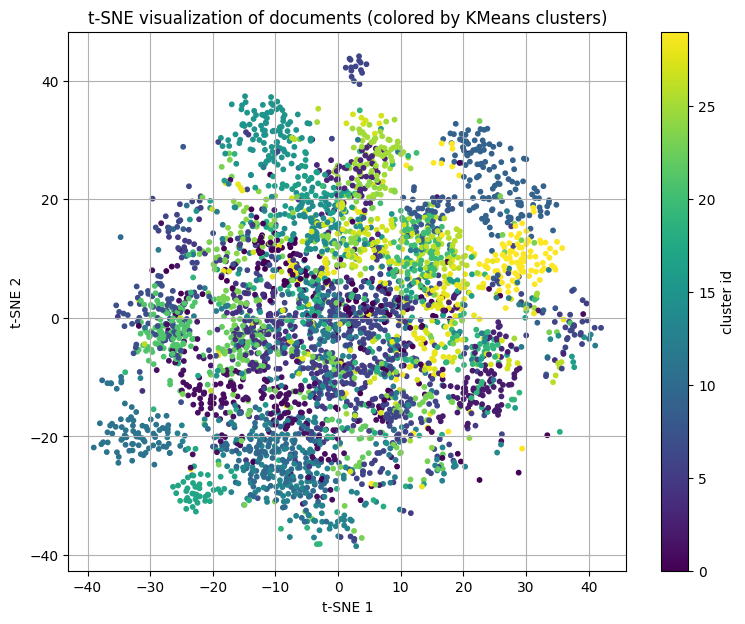

In [28]:
# Use a smaller sample for t-SNE if you have many docs (speeds up a lot)
n_sample = min(4000, len(df))
idx = np.random.choice(len(df), size=n_sample, replace=False)

X_vis_base = x_lsa[idx]
labels_vis = km_labels[idx]

tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
X_2d = tsne.fit_transform(X_vis_base)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_vis, s=10)
ax.set_title("t-SNE visualization of documents (colored by KMeans clusters)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="cluster id")
plt.show()

In [27]:
# To interpret KMeans in TF-IDF space, fit KMeans directly on TF-IDF too (optional),
# BUT we can still interpret LSA KMeans by mapping back using centroids in TF-IDF
# The simpler approach: fit KMeans on TF-IDF for top terms extraction.

km_tfidf = KMeans(n_clusters=k, n_init=20, random_state=42)
labels_tfidf = km_tfidf.fit_predict(X_tfidf)

order_centroids = km_tfidf.cluster_centers_.argsort(axis=1)[:, ::-1]

top_n = 12
for cluster_id in range(k):
    top_terms = feature_names[order_centroids[cluster_id, :top_n]]
    print(f"\nCluster {cluster_id} top terms:", ", ".join(top_terms))

    # show a few example docs from this cluster
    example_idx = df.index[labels_tfidf == cluster_id].to_numpy()
    if len(example_idx) == 0:
        continue
    picks = np.random.choice(example_idx, size=min(3, len(example_idx)), replace=False)

    for j, pi in enumerate(picks, 1):
        snippet = textwrap.shorten(df.loc[pi, "clean_text"], width=240)
        print(f"  Example {j}: {snippet}")


Cluster 0 top terms: graphics, uk, ac, comp graphics, comp, computer graphics, ac uk, computer, uk ac, lilley, 44, faq
  Example 1: RADIOSITY SOURCES WANTED !!! ============================ When I read the comp.graphics group, I never found something about radiosity. Is there anybody interested in out there? I would be glad to hear from somebody. I am looking for [...]
  Example 2: I'm currently looking for a viewer for Computer Graphics Metafile (CGM) pictures. Please inform me about a SHAREWARE or FREEWARE version. Thnx, Remco
  Example 3: Recently I saw the latest Computer Shopper and in it there was an article on nice shareware graphics programs. They looked pretty good and of the 6 listed in the article, one I had (Graphics Workshop), one I found via archie (Draft [...]

Cluster 1 top terms: think, don, people, just, know, like, did, say, time, fbi, believe, really
  Example 1: Yes. Reasonable parallels. (though I don't think Russia ever claimed to be Communist) I must protest yo

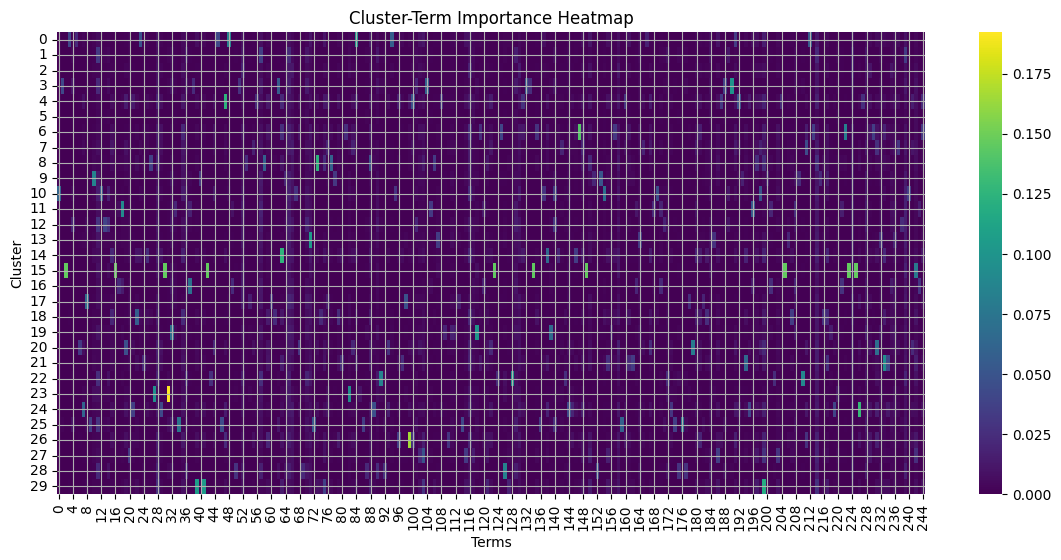

In [29]:
import seaborn as sns

top_n = 10
top_terms_all = []

for cluster_id in range(k):
    top_terms_all.extend(feature_names[order_centroids[cluster_id, :top_n]])

top_terms_unique = list(set(top_terms_all))

term_indices = [np.where(feature_names == t)[0][0] for t in top_terms_unique]

heatmap_data = km_tfidf.cluster_centers_[:, term_indices]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="viridis")
plt.title("Cluster-Term Importance Heatmap")
plt.xlabel("Terms")
plt.ylabel("Cluster")
plt.show()

In [31]:
!pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)


In [ ]:
import ipywidgets as widgets
from IPython.display import display

def show_cluster(cluster_id):
    print(f"\nCluster {cluster_id}")
    top_terms = feature_names[order_centroids[cluster_id, :12]]
    print("Top terms:", ", ".join(top_terms))

    example_idx = df.index[labels_tfidf == cluster_id].to_numpy()
    if len(example_idx) > 0:
        picks = np.random.choice(example_idx, size=min(5, len(example_idx)), replace=False)
        for i in picks:
            print("\n---")
            print(textwrap.fill(df.loc[i, "clean_text"][:400], width=80))

dropdown = widgets.Dropdown(
    options=list(range(k)),
    description="Cluster:"
    
)

widgets.interact(show_cluster, cluster_id=dropdown)